In [1]:
import networkx as nx
from neo4j_to_networkx import Neo4jToNetworkx
from dotenv import load_dotenv
import os
from neo4j import GraphDatabase
import matplotlib.pyplot as plt
import numpy as np
import json
from sklearn.manifold import MDS
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

load_dotenv()

driver = GraphDatabase.driver(
    os.getenv("NEO4J_DSN"),
    auth=(os.getenv("NEO4J_USER"), os.getenv("NEO4J_PASSWORD")),
)

In [2]:
def visualize_concept(concept_graph: nx.Graph):
    # Extract node positions from the graph
    pos = {}
    for node_id, node_data in concept_graph.nodes(data=True):
        # For regular points
        if 'x' in node_data and 'y' in node_data:
            x = json.loads(node_data['x'])['center']
            y = json.loads(node_data['y'])['center']
                
            pos[node_id] = (x, y)
            
        if 'labels' in node_data and 'Vector' in node_data['labels']:
                x1 = json.loads(node_data['x1'])
                x2 = json.loads(node_data['x2'])
                y1 = json.loads(node_data['y1'])
                y2 = json.loads(node_data['y2'])
                
                x1 = x1['center'] if isinstance(x1, dict) and 'center' in x1 else x1
                x2 = x2['center'] if isinstance(x2, dict) and 'center' in x2 else x2
                y1 = y1['center'] if isinstance(y1, dict) and 'center' in y1 else y1
                y2 = y2['center'] if isinstance(y2, dict) and 'center' in y2 else y2
                
                pos[node_id] = (x1, y1)
    
    # Create figure
    plt.figure(figsize=(12, 10))
    
    # Draw nodes with different colors based on labels
    node_colors = []
    for _, data in concept_graph.nodes(data=True):
        if 'labels' in data:
            if 'StartPoint' in data['labels']:
                node_colors.append('green')
            elif 'CornerPoint' in data['labels']:
                node_colors.append('red')
            elif 'Vector' in data['labels']:
                node_colors.append('blue')
            else:
                node_colors.append('gray')
        else:
            node_colors.append('gray')
    
    # Draw the graph
    nx.draw_networkx(
        concept_graph,
        pos=pos,
        with_labels=True,
        node_size=100,
        node_color=node_colors,
        edge_color='black',
        width=1.0,
        alpha=0.8
    )
    
    # Add a legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='StartPoint'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='CornerPoint'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Vector'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Other'),
        plt.Line2D([0], [0], color='blue', lw=2, label='Vector Direction')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    
    plt.title('Concept Graph Visualization')
    plt.axis('equal')  # Equal aspect ratio
    plt.grid(True)
    plt.gca().invert_yaxis()  # Invert y-axis to match image coordinates
    plt.tight_layout()
    
    return plt.gcf()  # Return the figure for further customization if needed

In [3]:
def parse_graph_properties(graph: nx.Graph) -> nx.Graph:
    """Parse JSON string properties to Python objects (dicts, lists, numbers).
    
    The concept_creator's Neo4jToNetworkx stores all properties as raw strings.
    The classification pipeline parses them (see classification/repository/neo4j_to_networkx.py:37-45).
    We replicate that parsing here so GED cost functions receive dicts, not strings.
    """
    for node_id, data in graph.nodes(data=True):
        parsed = {}
        for key, value in data.items():
            if isinstance(value, str):
                try:
                    parsed[key] = json.loads(value)
                except (json.JSONDecodeError, TypeError):
                    parsed[key] = value
            else:
                parsed[key] = value
        # Convert labels list to set (matching classification pipeline)
        if 'labels' in parsed and isinstance(parsed['labels'], list):
            parsed['labels'] = set(parsed['labels'])
        nx.set_node_attributes(graph, {node_id: parsed})
    return graph

# Load all concept graphs
with driver.session() as session:
    result = session.run(
        "MATCH (n) WHERE n.concept_id IS NOT NULL "
        "RETURN DISTINCT n.concept_id AS cid ORDER BY cid"
    )
    concept_ids = sorted([r['cid'] for r in result])

concept_graphs = {}
with driver.session() as session:
    for cid in concept_ids:
        graph = Neo4jToNetworkx.extract_concept_graph(session, cid)
        concept_graphs[cid] = parse_graph_properties(graph)

# Compute complexities (nodes + edges, matching classification)
complexities = {cid: len(g.nodes) + len(g.edges) for cid, g in concept_graphs.items()}

print(f"Loaded {len(concept_ids)} concepts: {concept_ids}")
for cid in concept_ids:
    g = concept_graphs[cid]
    print(f"  {cid}: {len(g.nodes)} nodes, {len(g.edges)} edges, complexity={complexities[cid]}")

Loaded 13 concepts: ['0_1', '1_1', '1_3', '2_1', '2_2', '3_1', '4_1', '4_2', '5_1', '6_1', '7_1', '8_1', '9_2']
  0_1: 10 nodes, 10 edges, complexity=20
  1_1: 7 nodes, 6 edges, complexity=13
  1_3: 3 nodes, 2 edges, complexity=5
  2_1: 7 nodes, 6 edges, complexity=13
  2_2: 12 nodes, 12 edges, complexity=24
  3_1: 11 nodes, 10 edges, complexity=21
  4_1: 8 nodes, 8 edges, complexity=16
  4_2: 9 nodes, 8 edges, complexity=17
  5_1: 7 nodes, 6 edges, complexity=13
  6_1: 10 nodes, 10 edges, complexity=20
  7_1: 5 nodes, 4 edges, complexity=9
  8_1: 13 nodes, 14 edges, complexity=27
  9_2: 8 nodes, 8 edges, complexity=16


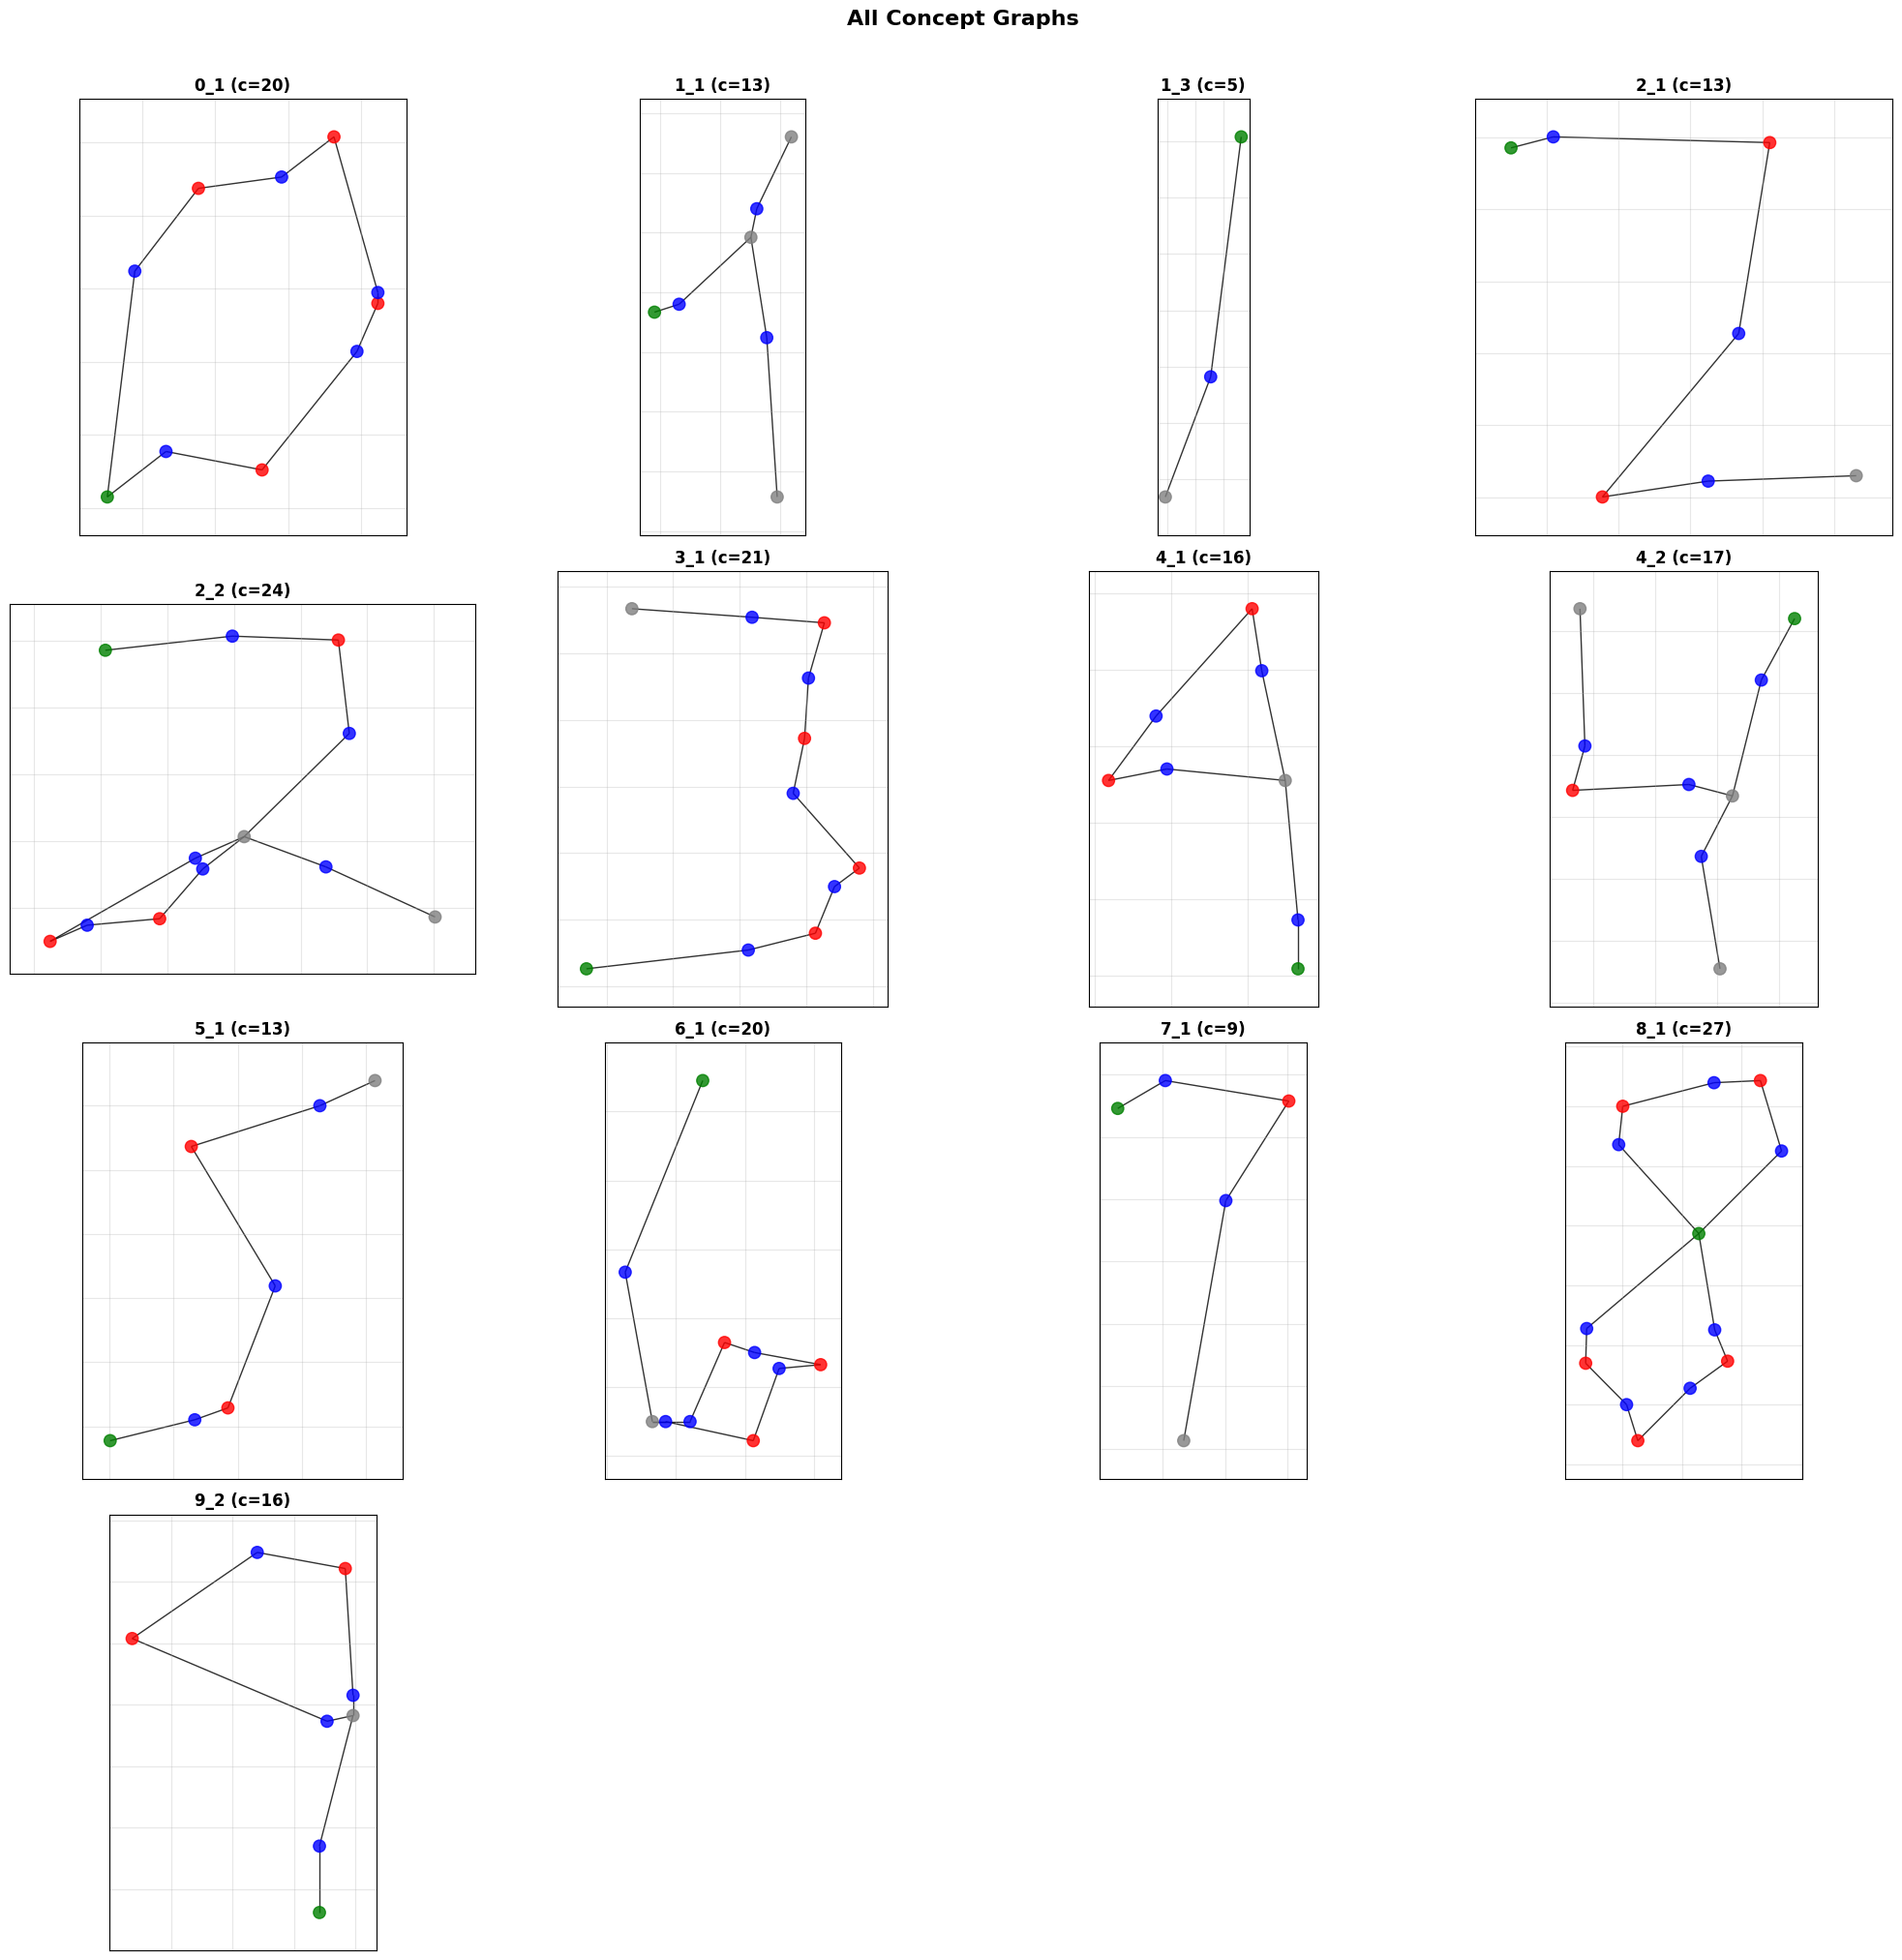

In [4]:
# --- All Concepts Grid Visualization ---
def get_concept_positions(concept_graph):
    """Extract node positions from concept graph for visualization."""
    pos = {}
    for node_id, node_data in concept_graph.nodes(data=True):
        labels = node_data.get('labels', set())
        if isinstance(labels, list):
            labels = set(labels)

        if 'Vector' in labels:
            x1 = node_data.get('x1', {})
            y1 = node_data.get('y1', {})
            x1 = x1['center'] if isinstance(x1, dict) and 'center' in x1 else x1
            y1 = y1['center'] if isinstance(y1, dict) and 'center' in y1 else y1
            if isinstance(x1, (int, float)) and isinstance(y1, (int, float)):
                pos[node_id] = (x1, y1)
        elif 'x' in node_data and 'y' in node_data:
            x = node_data['x']
            y = node_data['y']
            x = x['center'] if isinstance(x, dict) and 'center' in x else x
            y = y['center'] if isinstance(y, dict) and 'center' in y else y
            if isinstance(x, (int, float)) and isinstance(y, (int, float)):
                pos[node_id] = (x, y)
    return pos


def get_node_colors(concept_graph):
    """Get colors for nodes based on their type labels."""
    colors = []
    for _, data in concept_graph.nodes(data=True):
        labels = data.get('labels', set())
        if isinstance(labels, list):
            labels = set(labels)
        if 'StartPoint' in labels:
            colors.append('green')
        elif 'CornerPoint' in labels:
            colors.append('red')
        elif 'Vector' in labels:
            colors.append('blue')
        else:
            colors.append('gray')
    return colors


n = len(concept_ids)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = axes.flatten()

for idx, cid in enumerate(sorted(concept_ids, key=lambda x: (int(x.split('_')[0]), x))):
    ax = axes[idx]
    g = concept_graphs[cid]
    pos = get_concept_positions(g)
    node_colors = get_node_colors(g)

    # Only draw nodes that have positions
    nodes_with_pos = [n for n in g.nodes() if n in pos]
    subgraph = g.subgraph(nodes_with_pos)
    sub_pos = {n: pos[n] for n in nodes_with_pos}
    sub_colors = [node_colors[list(g.nodes()).index(n)] for n in nodes_with_pos]

    if sub_pos:
        nx.draw_networkx(
            subgraph, pos=sub_pos, ax=ax,
            with_labels=False, node_size=80,
            node_color=sub_colors, edge_color='black',
            width=1.0, alpha=0.8,
        )
        ax.invert_yaxis()

    ax.set_title(f'{cid} (c={complexities[cid]})', fontsize=12, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(concept_ids), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('All Concept Graphs', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [5]:
# --- Symmetric GED Cost Functions for Concept-to-Concept Comparison ---
# Adapted from classification/graph_similarity/cost_functions.py
# Key differences from classification:
#   1. node_ins_cost = 0.25 (symmetric), not IMPOSSIBLE (100.0)
#   2. Label check is symmetric (intersection), not directional (subset)
#   3. All properties are range-to-range (both concepts have range dicts)

FEATURES = [
    # Spatial / positional
    "normalized_x",
    "normalized_y",
    "distance_to_centroid",
    # Direction / angle
    "horizontal_direction",
    "vertical_direction",
    "angle_with_ox",
    "junction_angle_min",
    "junction_angle_max",
    "junction_angle_mean",
    # Degree / topology
    "node_degree",
    "is_endpoint",
    "is_junction",
    "is_corner",
    "is_on_cycle",
    "cycle_count",
    # Geometric / length
    "tortuosity",
    "normalized_length",
    "length_ratio_to_max",
    # Branch type
    "branch_type",
    "connects_cycle_nodes",
    # Centrality
    "betweenness_centrality",
    "closeness_centrality",
    "eccentricity",
    "pagerank",
    # Neighborhood context
    "avg_neighbor_vector_length",
    "neighbor_endpoint_count",
    "neighbor_junction_count",
    "neighbor_corner_count",
]

IMPOSSIBLE = 100.0
MINOR = 0.25


def _is_range(value):
    return isinstance(value, dict) and "min" in value and "max" in value and "center" in value


def _compare_ranges(range1, range2, max_cost):
    """Compare two range objects. Returns cost in [0, max_cost].
    Logic mirrors node_similarity_calculator.py:415-435 (center + overlap)."""
    c1, c2 = float(range1["center"]), float(range2["center"])
    min1, max1 = float(range1["min"]), float(range1["max"])
    min2, max2 = float(range2["min"]), float(range2["max"])

    # Center similarity (normalized — values are typically in [-1, 1] range)
    center_dist = abs(c1 - c2)
    max_possible = max(abs(c1), abs(c2), 1.0)
    center_similarity = max(0.0, 1.0 - center_dist / max_possible)

    # Range overlap
    overlap_start = max(min1, min2)
    overlap_end = min(max1, max2)
    overlap = max(0.0, overlap_end - overlap_start)
    range_w1 = max1 - min1
    range_w2 = max2 - min2
    max_range = max(range_w1, range_w2, 1e-9)
    overlap_ratio = overlap / max_range

    similarity = 0.6 * center_similarity + 0.4 * overlap_ratio
    return max_cost * (1.0 - similarity)


def _compare_values(val1, val2, max_cost):
    """Compare two property values. Returns cost in [0, max_cost]."""
    if val1 == val2:
        return 0.0

    if _is_range(val1) and _is_range(val2):
        return _compare_ranges(val1, val2, max_cost)

    # Both numbers
    if isinstance(val1, (int, float)) and isinstance(val2, (int, float)):
        if abs(val1 - val2) < 1e-10:
            return 0.0
        return max_cost

    # Both strings
    if isinstance(val1, str) and isinstance(val2, str):
        return 0.0 if val1.lower() == val2.lower() else max_cost

    return max_cost


def sym_node_subst_cost(data1, data2):
    """Symmetric node substitution cost for concept-to-concept GED."""
    labels1 = data1.get("labels", set())
    labels2 = data2.get("labels", set())
    if isinstance(labels1, list):
        labels1 = set(labels1)
    if isinstance(labels2, list):
        labels2 = set(labels2)

    # Symmetric label check: must share at least one type
    if not (labels1 & labels2):
        return IMPOSSIBLE

    # Find common features present on both nodes
    common_features = [f for f in FEATURES if f in data1 and f in data2]
    if not common_features:
        return 1.0

    max_prop_penalty = 1.0 / len(common_features)
    total_cost = 0.0
    for feat in common_features:
        cost = _compare_values(data1[feat], data2[feat], max_prop_penalty)
        total_cost += min(cost, max_prop_penalty)

    return total_cost


def sym_node_del_cost(data):
    return MINOR

def sym_node_ins_cost(data):
    return MINOR  # Symmetric with deletion

def sym_edge_match(data1, data2):
    return True

def sym_edge_del_cost(data):
    return MINOR

def sym_edge_ins_cost(data):
    return 0.0

print("Symmetric GED cost functions defined.")

Symmetric GED cost functions defined.


In [6]:
# --- Compute Pairwise GED Distance Matrix ---
import time as _time

n = len(concept_ids)
distance_matrix = np.zeros((n, n))
raw_ged_matrix = np.zeros((n, n))

total_pairs = n * (n - 1) // 2
pair_count = 0
t_start = _time.time()

for i in range(n):
    for j in range(i + 1, n):
        pair_count += 1
        cid_i, cid_j = concept_ids[i], concept_ids[j]
        g_i, g_j = concept_graphs[cid_i], concept_graphs[cid_j]

        t0 = _time.time()
        ged = nx.graph_edit_distance(
            g_i, g_j,
            node_subst_cost=sym_node_subst_cost,
            node_del_cost=sym_node_del_cost,
            node_ins_cost=sym_node_ins_cost,
            edge_match=sym_edge_match,
            edge_del_cost=sym_edge_del_cost,
            edge_ins_cost=sym_edge_ins_cost,
        )
        elapsed = _time.time() - t0

        max_possible = max(len(g_i) + len(g_j), 1)
        normalized_dist = ged / max_possible

        raw_ged_matrix[i, j] = raw_ged_matrix[j, i] = ged
        distance_matrix[i, j] = distance_matrix[j, i] = normalized_dist

        print(f"  [{pair_count:>3}/{total_pairs}] {cid_i:>4} vs {cid_j:<4} "
              f"({len(g_i)}+{len(g_j)} nodes) "
              f"GED={ged:>6.2f}  norm={normalized_dist:.3f}  ({elapsed:.1f}s)")

total_time = _time.time() - t_start
print(f"\nCompleted {total_pairs} pairs in {total_time:.1f}s.")

# Print formatted distance table
header = f"{'':>6}" + "".join(f"{cid:>8}" for cid in concept_ids)
print(f"\nNormalized Distance Matrix:\n{header}")
for i, cid_i in enumerate(concept_ids):
    row = f"{cid_i:>6}" + "".join(f"{distance_matrix[i,j]:>8.3f}" for j in range(n))
    print(row)

  [  1/78]  0_1 vs 1_1  (10+7 nodes) GED=  5.52  norm=0.325  (0.8s)
  [  2/78]  0_1 vs 1_3  (10+3 nodes) GED=  5.47  norm=0.421  (0.0s)
  [  3/78]  0_1 vs 2_1  (10+7 nodes) GED=  4.40  norm=0.259  (0.0s)
  [  4/78]  0_1 vs 2_2  (10+12 nodes) GED=  3.50  norm=0.159  (0.3s)
  [  5/78]  0_1 vs 3_1  (10+11 nodes) GED=  4.03  norm=0.192  (0.6s)
  [  6/78]  0_1 vs 4_1  (10+8 nodes) GED=  3.64  norm=0.202  (0.3s)
  [  7/78]  0_1 vs 4_2  (10+9 nodes) GED=  4.70  norm=0.248  (0.6s)
  [  8/78]  0_1 vs 5_1  (10+7 nodes) GED=  4.39  norm=0.258  (0.0s)
  [  9/78]  0_1 vs 6_1  (10+10 nodes) GED=  2.50  norm=0.125  (0.1s)
  [ 10/78]  0_1 vs 7_1  (10+5 nodes) GED=  4.90  norm=0.327  (0.0s)
  [ 11/78]  0_1 vs 8_1  (10+13 nodes) GED=  3.26  norm=0.142  (1.5s)
  [ 12/78]  0_1 vs 9_2  (10+8 nodes) GED=  3.08  norm=0.171  (0.2s)
  [ 13/78]  1_1 vs 1_3  (7+3 nodes) GED=  3.11  norm=0.311  (0.0s)
  [ 14/78]  1_1 vs 2_1  (7+7 nodes) GED=  2.56  norm=0.183  (0.0s)
  [ 15/78]  1_1 vs 2_2  (7+12 nodes) GED=  3.9

In [7]:
# --- MDS Projection to 2D ---
mds = MDS(
    n_components=2,
    dissimilarity='precomputed',
    normalized_stress='auto',
    n_init=10,
    max_iter=300,
    random_state=42,
)
coords_2d = mds.fit_transform(distance_matrix)
stress = mds.stress_

# Interpret stress quality
if stress < 0.025:
    quality = "excellent"
elif stress < 0.05:
    quality = "good"
elif stress < 0.1:
    quality = "fair"
else:
    quality = "poor"

print(f"MDS Stress-1: {stress:.4f} ({quality})")
print(f"\nProjected coordinates:")
for i, cid in enumerate(concept_ids):
    print(f"  {cid}: ({coords_2d[i, 0]:.3f}, {coords_2d[i, 1]:.3f})")

MDS Stress-1: 0.1660 (poor)

Projected coordinates:
  0_1: (-0.056, 0.188)
  1_1: (-0.050, -0.160)
  1_3: (0.207, -0.095)
  2_1: (-0.069, -0.045)
  2_2: (-0.090, 0.091)
  3_1: (-0.151, 0.021)
  4_1: (0.106, 0.062)
  4_2: (0.019, -0.060)
  5_1: (-0.098, -0.081)
  6_1: (-0.002, 0.102)
  7_1: (0.082, -0.176)
  8_1: (0.040, 0.138)
  9_2: (0.063, 0.018)


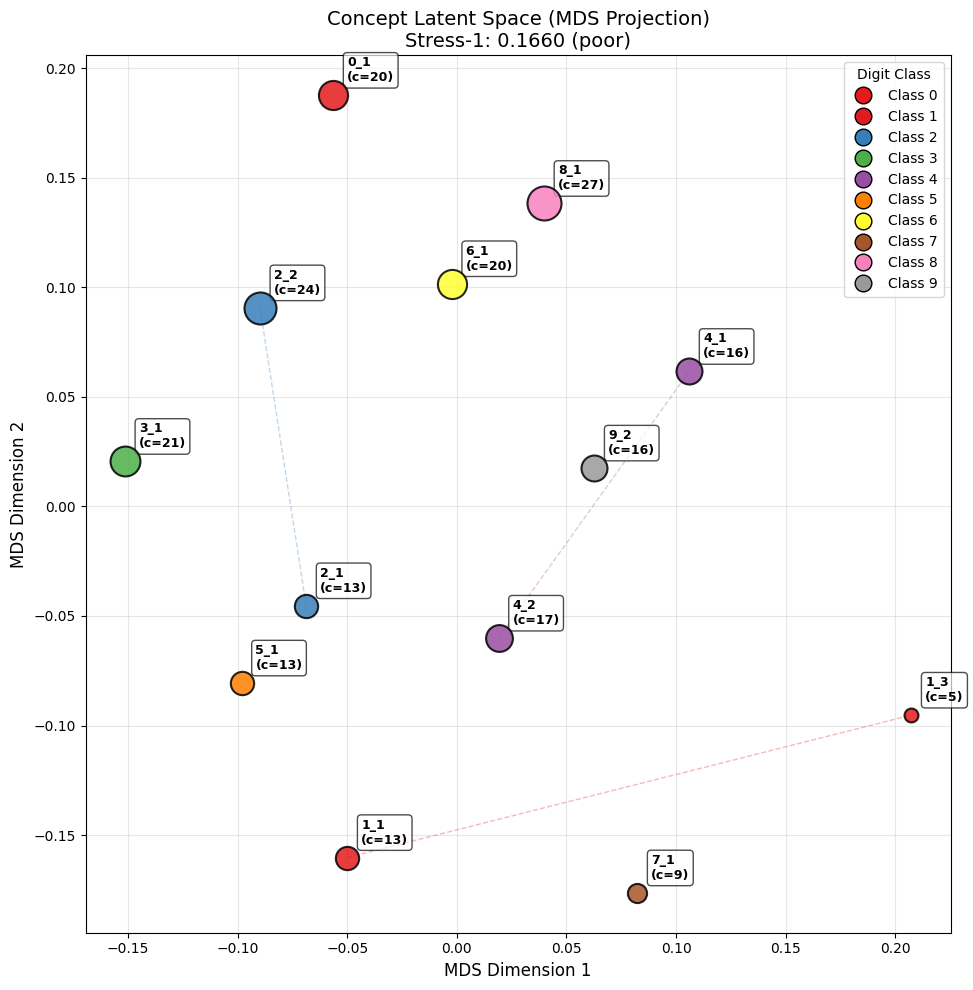

In [8]:
# --- Latent Space Scatter Plot ---
class_labels = [int(cid.split('_')[0]) for cid in concept_ids]
unique_classes = sorted(set(class_labels))
cmap = plt.cm.Set1
color_map = {c: cmap(i / max(len(unique_classes), 1)) for i, c in enumerate(unique_classes)}

# Scale marker size by complexity
comp_values = [complexities[cid] for cid in concept_ids]
min_c, max_c = min(comp_values), max(comp_values)
sizes = [100 + 500 * (c - min_c) / max(max_c - min_c, 1) for c in comp_values]

fig, ax = plt.subplots(figsize=(12, 10))

for i, (cid, cls, sz) in enumerate(zip(concept_ids, class_labels, sizes)):
    ax.scatter(
        coords_2d[i, 0], coords_2d[i, 1],
        c=[color_map[cls]], s=sz, alpha=0.85,
        edgecolors='black', linewidths=1.5, zorder=5,
    )
    ax.annotate(
        f"{cid}\n(c={complexities[cid]})",
        (coords_2d[i, 0], coords_2d[i, 1]),
        textcoords="offset points", xytext=(10, 10),
        fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7),
    )

# Draw lines between same-class concepts
for cls in unique_classes:
    indices = [i for i, c in enumerate(class_labels) if c == cls]
    if len(indices) > 1:
        for a, b in combinations(indices, 2):
            ax.plot(
                [coords_2d[a, 0], coords_2d[b, 0]],
                [coords_2d[a, 1], coords_2d[b, 1]],
                color=color_map[cls], alpha=0.3, linestyle='--', linewidth=1,
            )

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=color_map[c], markersize=12,
               markeredgecolor='black', label=f'Class {c}')
    for c in unique_classes
]
ax.legend(handles=legend_handles, title='Digit Class', loc='upper right', fontsize=10)

ax.set_title(f'Concept Latent Space (MDS Projection)\nStress-1: {stress:.4f} ({quality})',
             fontsize=14)
ax.set_xlabel('MDS Dimension 1', fontsize=12)
ax.set_ylabel('MDS Dimension 2', fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

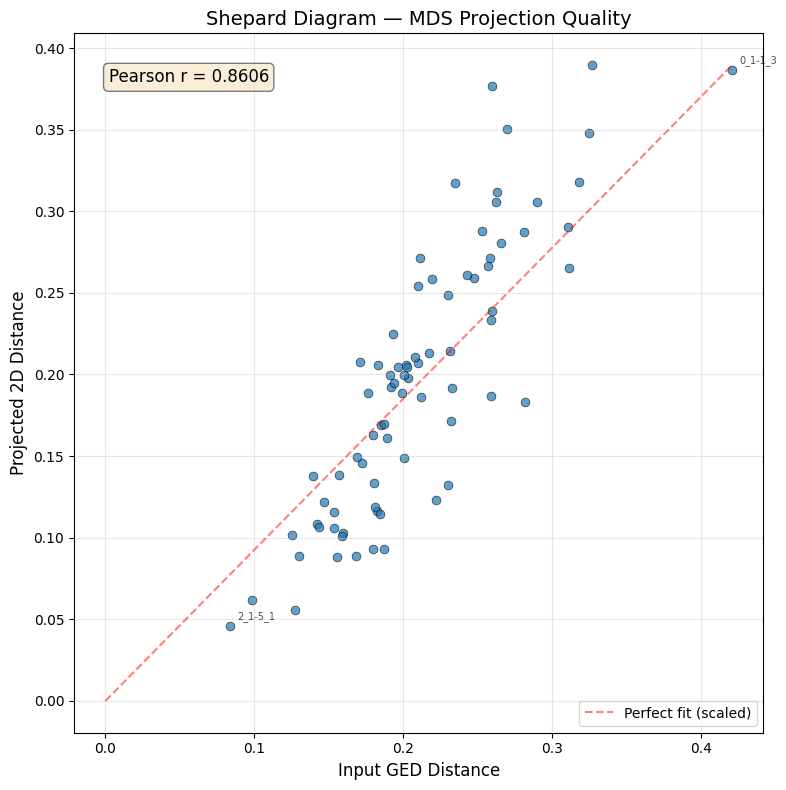

Pearson correlation: 0.8606
(r > 0.95 = excellent preservation of distances)


In [9]:
# --- Shepard Diagram (Projection Quality Validation) ---
projected_dists = squareform(pdist(coords_2d))

input_dists = []
proj_dists = []
pair_labels = []
for i in range(n):
    for j in range(i + 1, n):
        input_dists.append(distance_matrix[i, j])
        proj_dists.append(projected_dists[i, j])
        pair_labels.append(f"{concept_ids[i]}-{concept_ids[j]}")

input_dists = np.array(input_dists)
proj_dists = np.array(proj_dists)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(input_dists, proj_dists, alpha=0.7, s=40, edgecolors='black', linewidths=0.5)

# Perfect fit reference line (scaled)
max_input = input_dists.max()
max_proj = proj_dists.max()
scale = max_proj / max_input if max_input > 0 else 1
ax.plot([0, max_input], [0, max_input * scale], 'r--', alpha=0.5, label='Perfect fit (scaled)')

# Annotate a few extreme points
for idx in [np.argmax(input_dists), np.argmin(input_dists)]:
    ax.annotate(pair_labels[idx], (input_dists[idx], proj_dists[idx]),
                textcoords="offset points", xytext=(5, 5), fontsize=7, alpha=0.7)

corr = np.corrcoef(input_dists, proj_dists)[0, 1]
ax.text(0.05, 0.95, f'Pearson r = {corr:.4f}', transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Input GED Distance', fontsize=12)
ax.set_ylabel('Projected 2D Distance', fontsize=12)
ax.set_title('Shepard Diagram — MDS Projection Quality', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Pearson correlation: {corr:.4f}")
print("(r > 0.95 = excellent preservation of distances)")

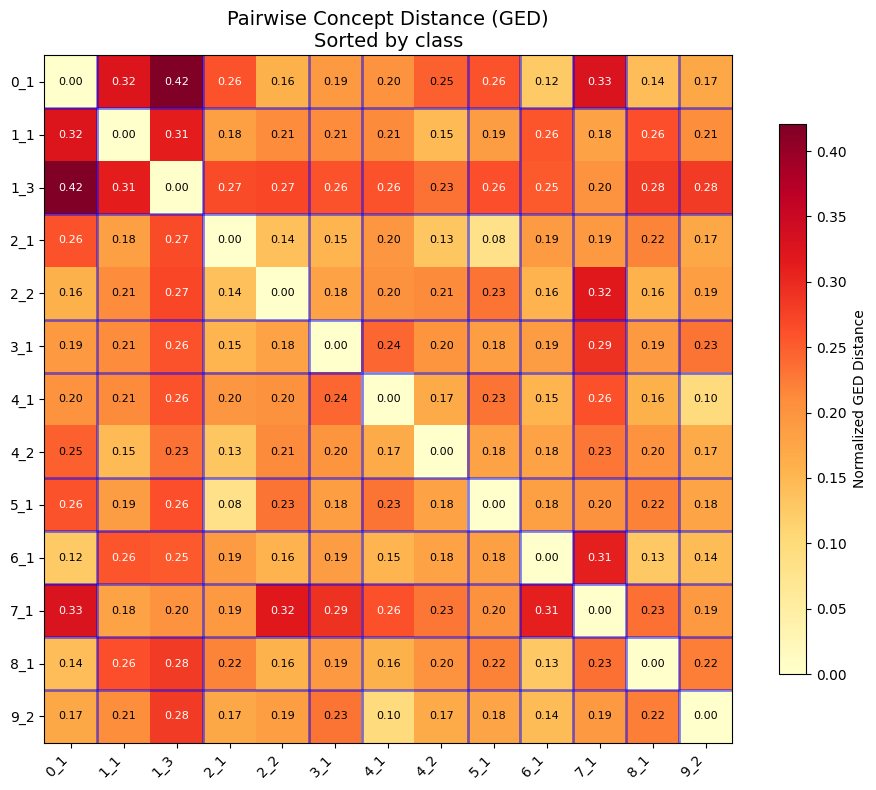

In [10]:
# --- Distance Heatmap ---
# Sort by class for cleaner grouping
sorted_indices = sorted(range(n), key=lambda i: (class_labels[i], concept_ids[i]))
sorted_ids = [concept_ids[i] for i in sorted_indices]
sorted_matrix = distance_matrix[np.ix_(sorted_indices, sorted_indices)]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sorted_matrix, cmap='YlOrRd', aspect='equal')

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(sorted_ids, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(sorted_ids, fontsize=10)

# Annotate cells with values
for i in range(n):
    for j in range(n):
        val = sorted_matrix[i, j]
        color = 'white' if val > sorted_matrix.max() * 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)

# Draw class group boundaries
class_of_sorted = [class_labels[i] for i in sorted_indices]
for k in range(1, n):
    if class_of_sorted[k] != class_of_sorted[k - 1]:
        ax.axhline(y=k - 0.5, color='blue', linewidth=2, alpha=0.5)
        ax.axvline(x=k - 0.5, color='blue', linewidth=2, alpha=0.5)

plt.colorbar(im, ax=ax, label='Normalized GED Distance', shrink=0.8)
ax.set_title('Pairwise Concept Distance (GED)\nSorted by class', fontsize=14)
plt.tight_layout()
plt.show()